In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import importlib
import pdslasso
import sim_data
from typing import Tuple, Dict, Any
import matplotlib.pyplot as plt 
import seaborn as sns 

# Force Python to re-read the file from disk
importlib.reload(sim_data)
importlib.reload(pdslasso)

<module 'pdslasso' from '/Users/ralfblochlinger/Documents/GitHub/post-double-selection-lasso/pdslasso.py'>

In [2]:
# example with simulated data
BETA = 3    

df, meta = sim_data.simulate_pds_data(true_effect=BETA)
control_cols = [col for col in df.columns if col.startswith("x")]
y_col = "y"
d_col = "d"

pds_lasso_obj = pdslasso.PDSLasso(df, y_col, d_col, control_cols)

fit_lasso = pds_lasso_obj.fit()
print(pds_lasso_obj.selected_controls)
fit_lasso.summary()

['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     447.5
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:06:40   Log-Likelihood:                -2113.2
No. Observations:                1000   AIC:                             4248.
Df Residuals:                     989   BIC:                             4302.
Df Model:                          10                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.120     -0.011      0.992      -0.237       0.235
d              3.0577      0.196     15.606      0.000       2.674       3.442
x0             1.9476      0.080     24.493      0.000       1.792       2.103
x1            -1.4746      0.074    -20.021      0.000      -1.619      -1.330
x2             1.1046      0.068     16.181      0.000       0.971       1.238
x3             0.0767      0.070      1.091      0.275      -0.061       0.215
x4             0.0748      0.067      1.109      0.268      -0.057       0.207
x5            -0.0176      0.069     -0.255      0.799      -0.153       0.118
x6             0.9847      0.062     15.808      0.000       0.863       1.107
x7             0.9309      0.059     15.746      0.000       0.815       1.047
x8             1.1019      0.062     17.701      0.000       0.980       1.224
==============================================================================
Omnibus:                        0.778   Durbin-Watson:                   1.898
Prob(Omnibus):                  0.678   Jarque-Bera (JB):                0.863
Skew:                          -0.048   Prob(JB):                        0.650
Kurtosis:                       2.894   Cond. No.                         4.36
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [3]:
# monte carlo simulation
beta_hat_list = []

N_sim = 500

for i in range(N_sim):

    df, meta = sim_data.simulate_pds_data(true_effect=BETA, random_seed=i)
    control_cols = [col for col in df.columns if col.startswith("x")]
    y_col = "y"
    d_col = "d"

    pds_lasso_obj = pdslasso.PDSLasso(df, y_col, d_col, control_cols)
    fit_lasso = pds_lasso_obj.fit()
    beta_hat_pds = fit_lasso.params["d"]

    # regular lasso
    X_controls = pd.DataFrame(StandardScaler().fit_transform(df[control_cols]))
    X_controls.columns = control_cols
    X = pd.concat([df[d_col], X_controls], axis=1)
    y = df[y_col]

    regular_lasso = LassoCV().fit(X,y)
    beta_hat_lasso = regular_lasso.coef_[0]

    # regular regression
    regular_reg = sm.OLS(endog=y, exog=sm.add_constant(df[d_col])).fit()
    beta_hat_ols = regular_reg.params["d"]

    beta_hat_list.append({
        "pds": beta_hat_pds, 
        "lasso": beta_hat_lasso, 
        "ols": beta_hat_ols
        })
    

beta_hat_df = pd.DataFrame(beta_hat_list)

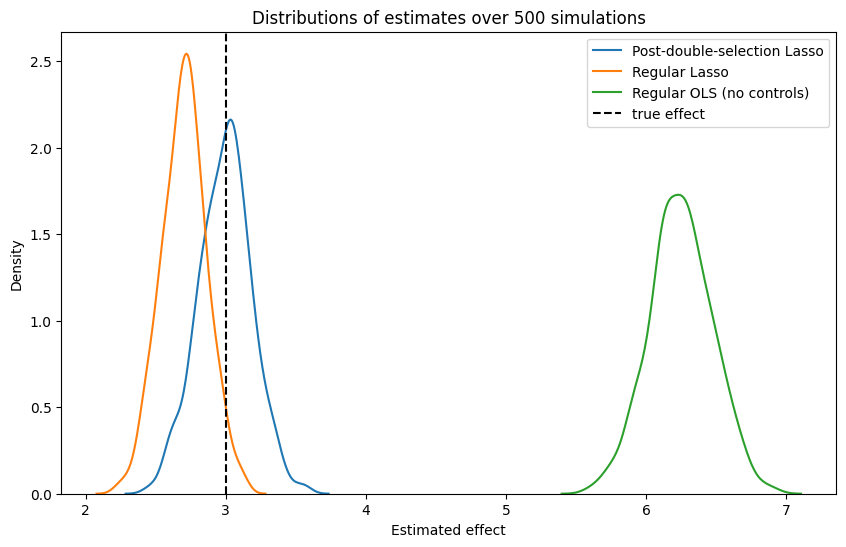

In [4]:
# plot distributions of estimates 
plt.figure(figsize=(10,6))
sns.kdeplot(beta_hat_df["pds"], label="Post-double-selection Lasso")
sns.kdeplot(beta_hat_df["lasso"], label="Regular Lasso")
sns.kdeplot(beta_hat_df["ols"], label="Regular OLS (no controls)")
plt.axvline(BETA, color="black", linestyle="--", label="true effect")
plt.legend()
plt.title(f"Distributions of estimates over {N_sim} simulations")
plt.xlabel("Estimated effect")
plt.ylabel("Density")
plt.show()